# MALBCV Data Exploration

This notebook explores the MALBCV training data available in this workspace. It prefers the header-normalized processed dataset under `data/processed`, and falls back to the original raw Synapse files under `data/raw` if needed.


In [38]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')

In [39]:
DATA_PROCESSED_ROOT = Path("../data/processed")
DATA_RAW_ROOT = Path("../data/raw")


def malbcv_label_path(label_dir, image_path):
    case_id = image_path.name.replace("_avg.nii.gz", "")
    return case_id, label_dir / f"{case_id}_avg_seg.nii.gz"


def build_malbcv_layout(root, name):
    label_dir = root / "averaged-training-labels"
    return {
        "name": name,
        "img_dir": root / "averaged-training-images",
        "label_dir": label_dir,
        "image_pattern": "*_avg.nii.gz",
        "label_for_image": lambda image_path, label_dir=label_dir: malbcv_label_path(label_dir, image_path),
        "label_names": {
            0: "Background", 1: "Spleen", 2: "Right Kidney", 3: "Left Kidney",
            4: "Gallbladder", 5: "Esophagus", 6: "Liver", 7: "Stomach",
            8: "Aorta", 9: "IVC", 10: "Portal & Splenic Veins", 11: "Pancreas",
            12: "Right Adrenal Gland", 13: "Left Adrenal Gland",
        },
        "label_colors": {
            1: "darkred", 2: "green", 3: "limegreen", 4: "cyan", 5: "red",
            6: "saddlebrown", 7: "orange", 8: "blue", 9: "purple",
            10: "magenta", 11: "yellow", 12: "salmon", 13: "lightgreen",
        },
        "intensity_label": "HU",
        "expected_cases": 84,
    }


LAYOUTS = [
    build_malbcv_layout(DATA_RAW_ROOT, "MALBCV averaged training"),
]


def discover_training_pairs(layouts):
    checked = []
    for layout in layouts:
        img_dir = layout["img_dir"]
        label_dir = layout["label_dir"]
        checked.append((layout["name"], img_dir, label_dir))
        if not img_dir.exists() or not label_dir.exists():
            continue

        pairs = []
        for ct_path in sorted(img_dir.glob(layout["image_pattern"])):
            case_id, gt_path = layout["label_for_image"](ct_path)
            if gt_path.exists():
                pairs.append((case_id, ct_path, gt_path))

        if pairs:
            return layout, pairs, checked

    checked_lines = [f"- {name}: img={img_dir} label={label_dir}" for name, img_dir, label_dir in checked]
    raise FileNotFoundError("No training image/label pairs found. Checked:\n" + "\n".join(checked_lines))


ACTIVE_LAYOUT, case_pairs, checked_layouts = discover_training_pairs(LAYOUTS)
IMG_DIR = ACTIVE_LAYOUT["img_dir"]
LABEL_DIR = ACTIVE_LAYOUT["label_dir"]
LABEL_NAMES = ACTIVE_LAYOUT["label_names"]
LABEL_COLORS = ACTIVE_LAYOUT["label_colors"]
INTENSITY_LABEL = ACTIVE_LAYOUT["intensity_label"]
EXPECTED_CASES = ACTIVE_LAYOUT["expected_cases"]
ct_files = [ct_path for _, ct_path, _ in case_pairs]

print(f"Using layout: {ACTIVE_LAYOUT['name']}")
print(f"Image dir: {IMG_DIR}")
print(f"Label dir: {LABEL_DIR}")
print(f"Found {len(case_pairs)} CT/label pairs")
print(f"Configured labels: {LABEL_NAMES}")
print(f"Intensity label: {INTENSITY_LABEL}")


Using layout: MALBCV averaged training
Image dir: ../data/raw/averaged-training-images
Label dir: ../data/raw/averaged-training-labels
Found 84 CT/label pairs
Configured labels: {0: 'Background', 1: 'Spleen', 2: 'Right Kidney', 3: 'Left Kidney', 4: 'Gallbladder', 5: 'Esophagus', 6: 'Liver', 7: 'Stomach', 8: 'Aorta', 9: 'IVC', 10: 'Portal & Splenic Veins', 11: 'Pancreas', 12: 'Right Adrenal Gland', 13: 'Left Adrenal Gland'}
Intensity label: HU


## 1. Load and Inspect a Single Patient

In [40]:
# Load first patient
case_id, ct_file, gt_file = case_pairs[0]

ct = nib.load(str(ct_file))
gt = nib.load(str(gt_file))

ct_data = ct.get_fdata()
gt_data = gt.get_fdata()
spacing = ct.header.get_zooms()
unique_labels = [int(v) for v in np.unique(gt_data)]

print(f"Case ID: {case_id}")
print(f"CT shape: {ct_data.shape}")
print(f"GT shape: {gt_data.shape}")
print(f"Voxel spacing: {spacing} mm")
print(f"{INTENSITY_LABEL} range: [{ct_data.min():.0f}, {ct_data.max():.0f}]")
print(f"Unique labels: {unique_labels}")
print(f"Affine matrix:\n{ct.affine}")

print("\nVoxel counts per label:")
for label, name in LABEL_NAMES.items():
    count = int(np.sum(gt_data == label))
    print(f"  {name:25s}: {count:>10,} voxels ({100 * count / gt_data.size:.3f}%)")


Case ID: 0001
CT shape: (512, 512, 147)
GT shape: (512, 512, 147)
Voxel spacing: (np.float32(0.66796875), np.float32(0.66796875), np.float32(3.0)) mm
HU range: [-1024, 2639]
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Affine matrix:
[[  -0.66796875    0.            0.          170.66601562]
 [   0.            0.66796875    0.         -170.66601562]
 [   0.            0.            3.         -219.        ]
 [   0.            0.            0.            1.        ]]

Voxel counts per label:
  Background               : 36,106,723 voxels (93.698%)
  Spleen                   :    232,705 voxels (0.604%)
  Right Kidney             :    151,047 voxels (0.392%)
  Left Kidney              :    128,383 voxels (0.333%)
  Gallbladder              :      6,245 voxels (0.016%)
  Esophagus                :     11,334 voxels (0.029%)
  Liver                    :  1,298,572 voxels (3.370%)
  Stomach                  :    349,669 voxels (0.907%)
  Aorta                    :     56,88

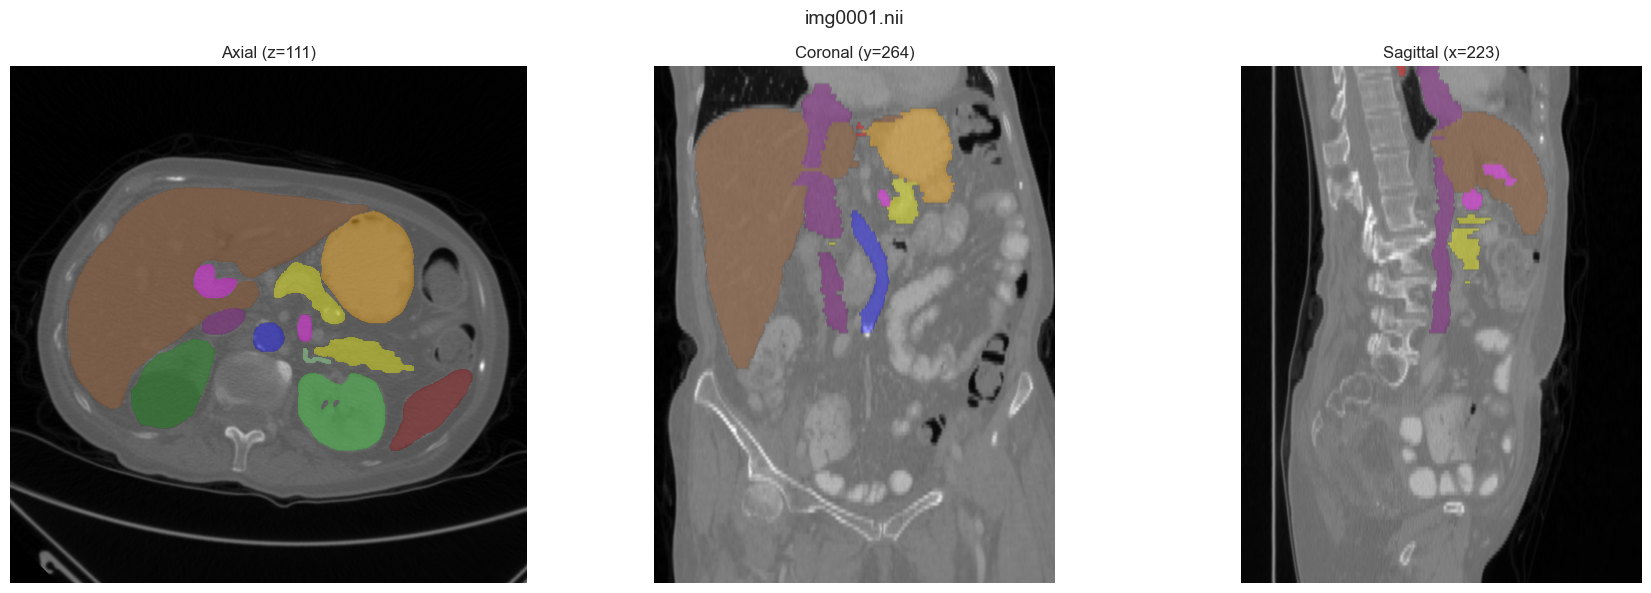

In [41]:
def plot_views(ct_data, gt_data, patient_name, spacing):
    """Plot axial, sagittal, and coronal views with label overlay."""
    sx, sy, sz = spacing[:3]

    fg_coords = np.argwhere(gt_data > 0)
    if len(fg_coords) == 0:
        print(f"No foreground in {patient_name}")
        return
    center = fg_coords.mean(axis=0).astype(int)

    rgba_colors = {
        label: plt.matplotlib.colors.to_rgba(color, alpha=0.4)
        for label, color in LABEL_COLORS.items()
    }

    slices = [
        (ct_data[:, :, center[2]], gt_data[:, :, center[2]], f"Axial (z={center[2]})", sy / sx),
        (ct_data[:, center[1], :], gt_data[:, center[1], :], f"Coronal (y={center[1]})", sz / sx),
        (ct_data[center[0], :, :], gt_data[center[0], :, :], f"Sagittal (x={center[0]})", sz / sy),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(patient_name, fontsize=14)

    for ax, (ct_sl, gt_sl, title, aspect) in zip(axes, slices):
        ax.imshow(ct_sl.T, cmap="gray", origin="lower", aspect=aspect)
        overlay = np.zeros((*ct_sl.T.shape, 4))
        for label, color in rgba_colors.items():
            overlay[gt_sl.T == label] = color
        ax.imshow(overlay, origin="lower", aspect=aspect)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_views(ct_data, gt_data, ct_file.stem, spacing)


## 3. Dataset-Wide Statistics

In [42]:
stats = []

for case_id, ct_path, gt_path in tqdm(case_pairs, desc="Computing stats"):
    ct = nib.load(str(ct_path))
    gt = nib.load(str(gt_path))
    ct_data = ct.get_fdata()
    gt_data = gt.get_fdata()
    spacing = ct.header.get_zooms()

    info = {
        "patient": case_id,
        "shape_x": ct_data.shape[0],
        "shape_y": ct_data.shape[1],
        "shape_z": ct_data.shape[2],
        "spacing_x": float(spacing[0]),
        "spacing_y": float(spacing[1]),
        "spacing_z": float(spacing[2]),
        "intensity_min": float(ct_data.min()),
        "intensity_max": float(ct_data.max()),
        "intensity_mean": float(ct_data.mean()),
        "intensity_std": float(ct_data.std()),
    }

    total_voxels = gt_data.size
    for label, name in LABEL_NAMES.items():
        key = name.lower().replace(" ", "_").replace("&", "and")
        count = int(np.sum(gt_data == label))
        info[f"voxels_{key}"] = count
        info[f"pct_{key}"] = 100 * count / total_voxels

    unexpected = sorted(int(v) for v in np.unique(gt_data) if int(v) not in LABEL_NAMES)
    info["unexpected_labels"] = unexpected
    stats.append(info)

print(f"Collected stats for {len(stats)} patients")


Computing stats: 100%|██████████| 30/30 [00:33<00:00,  1.12s/it]

Collected stats for 30 patients


In [43]:
import pandas as pd
df = pd.DataFrame(stats)
df.set_index('patient', inplace=True)
df.head()

,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,intensity_min,intensity_max,intensity_mean,intensity_std,...,pct_ivc,voxels_portal_and_splenic_veins,pct_portal_and_splenic_veins,voxels_pancreas,pct_pancreas,voxels_right_adrenal_gland,pct_right_adrenal_gland,voxels_left_adrenal_gland,pct_left_adrenal_gland,unexpected_labels
patient,,,,,,,,,,,,,,,,,,,,,
0001,512,512,147,0.667969,0.667969,3.0,-1024.0,2639.0,-489.530460,499.521835,...,0.177088,33699,0.087450,84187,0.218468,3280,0.008512,4195,0.010886,[]
0002,512,512,139,0.720703,0.720703,3.0,-1024.0,2976.0,-566.959424,493.272499,...,0.149668,14160,0.038861,39162,0.107476,3169,0.008697,3867,0.010613,[]
0003,512,512,198,0.898438,0.898438,3.0,-1024.0,2976.0,-618.506622,487.464417,...,0.083320,14212,0.027381,35283,0.067977,1724,0.003321,3222,0.006208,[]
0004,512,512,140,0.593750,0.593750,3.0,-1024.0,2976.0,-492.099386,507.702213,...,0.170266,20792,0.056654,62429,0.170106,2529,0.006891,2351,0.006406,[]
0005,512,512,117,0.906250,0.906250,3.0,-1024.0,2861.0,-578.105636,482.041199,...,0.097480,27169,0.088582,47404,0.154557,2824,0.009207,4173,0.013606,[]


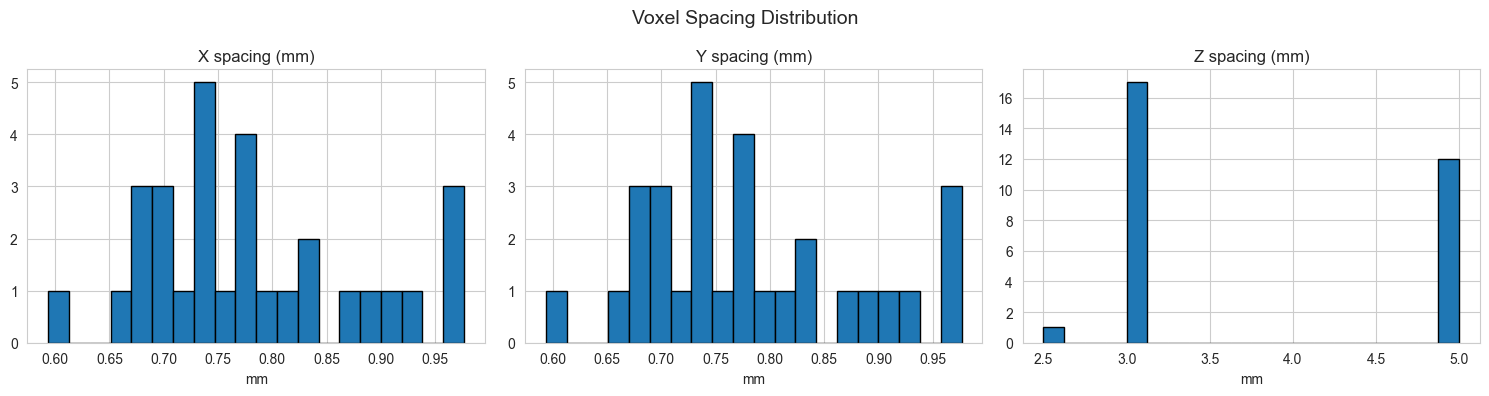

Spacing ranges:
  x: [0.59, 0.98] mm (mean: 0.78)
  y: [0.59, 0.98] mm (mean: 0.78)
  z: [2.50, 5.00] mm (mean: 3.78)


In [44]:
# Spacing distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dim in zip(axes, ['x', 'y', 'z']):
    ax.hist(df[f'spacing_{dim}'], bins=20, edgecolor='black')
    ax.set_title(f'{dim.upper()} spacing (mm)')
    ax.set_xlabel('mm')
plt.suptitle('Voxel Spacing Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print("Spacing ranges:")
for dim in ['x', 'y', 'z']:
    col = f'spacing_{dim}'
    print(f"  {dim}: [{df[col].min():.2f}, {df[col].max():.2f}] mm (mean: {df[col].mean():.2f})")

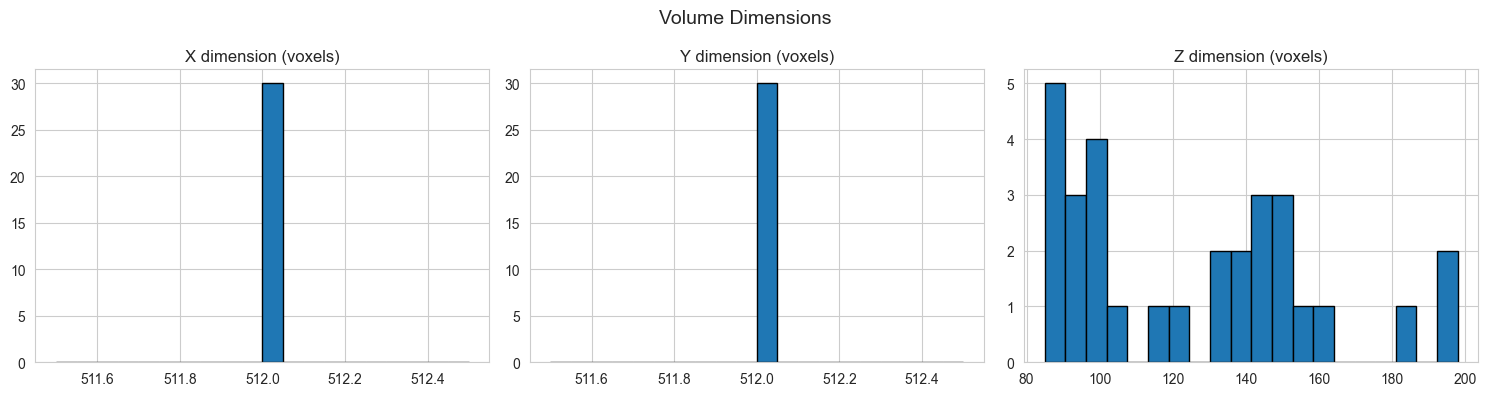

In [45]:
# Volume dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dim in zip(axes, ['x', 'y', 'z']):
    ax.hist(df[f'shape_{dim}'], bins=20, edgecolor='black')
    ax.set_title(f'{dim.upper()} dimension (voxels)')
plt.suptitle('Volume Dimensions', fontsize=14)
plt.tight_layout()
plt.show()

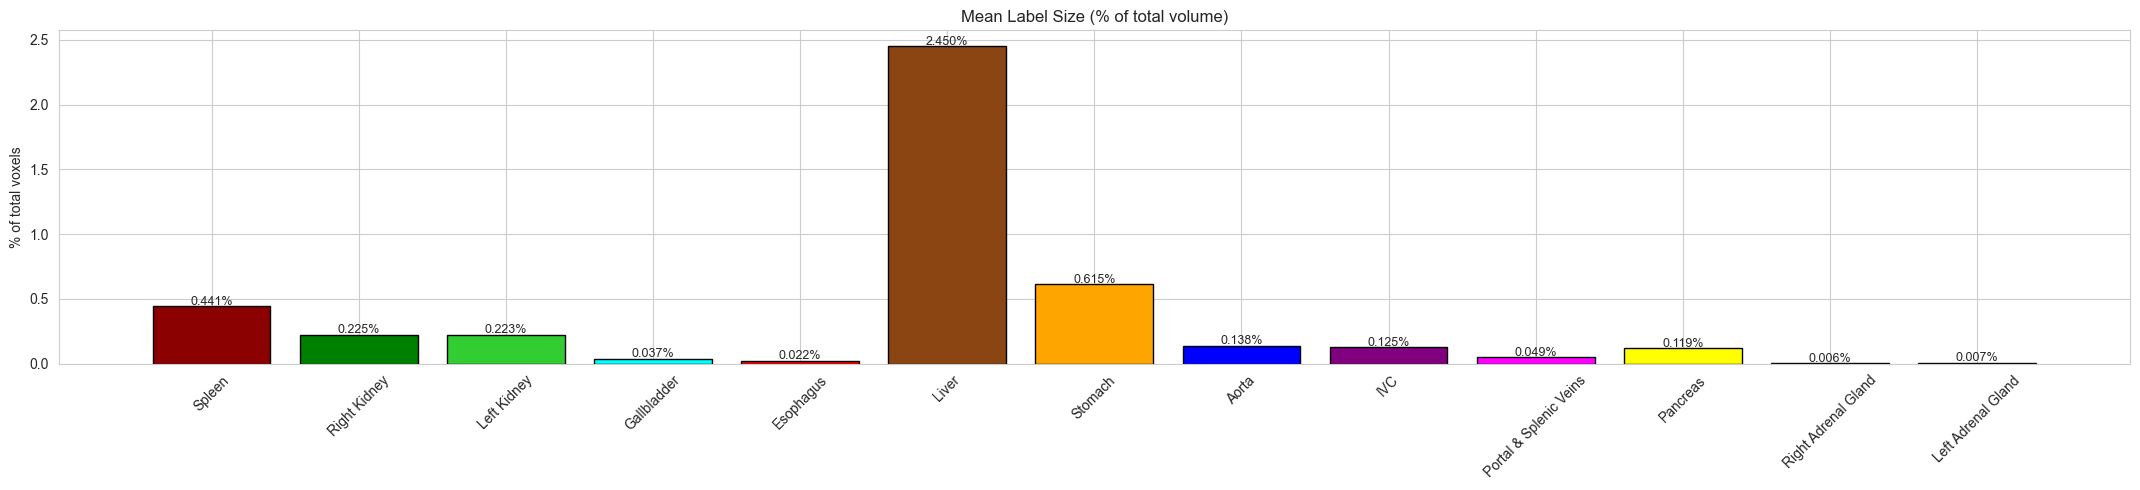

Relative label distribution (excluding background):
  Spleen              :  10.2%
  Right Kidney        :   5.0%
  Left Kidney         :   5.1%
  Gallbladder         :   0.8%
  Esophagus           :   0.5%
  Liver               :  54.4%
  Stomach             :  13.9%
  Aorta               :   3.1%
  IVC                 :   2.8%
  Portal & Splenic Veins:   1.1%
  Pancreas            :   2.6%
  Right Adrenal Gland :   0.1%
  Left Adrenal Gland  :   0.2%


In [46]:
# Label coverage / class imbalance
foreground_items = [(label, name) for label, name in LABEL_NAMES.items() if label != 0]
foreground_keys = [(label, name.lower().replace(" ", "_").replace("&", "and"), name) for label, name in foreground_items]

label_pcts = [df[f"pct_{key}"].mean() for _, key, _ in foreground_keys]
label_names = [name for _, _, name in foreground_keys]
label_colors = [LABEL_COLORS.get(label, "steelblue") for label, _, _ in foreground_keys]

fig, ax = plt.subplots(figsize=(max(6, 2 + 1.5 * len(label_names)), 5))
bars = ax.bar(label_names, label_pcts, color=label_colors, edgecolor="black")
ax.set_ylabel("% of total voxels")
ax.set_title("Mean Label Size (% of total volume)")
ax.tick_params(axis="x", rotation=45)
for bar, pct in zip(bars, label_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{pct:.3f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Relative label distribution (excluding background):")
total_fg = sum(df[f"voxels_{key}"].mean() for _, key, _ in foreground_keys)
for _, key, name in foreground_keys:
    mean_voxels = df[f"voxels_{key}"].mean()
    share = 100 * mean_voxels / total_fg if total_fg else 0.0
    print(f"  {name:20s}: {share:5.1f}%")


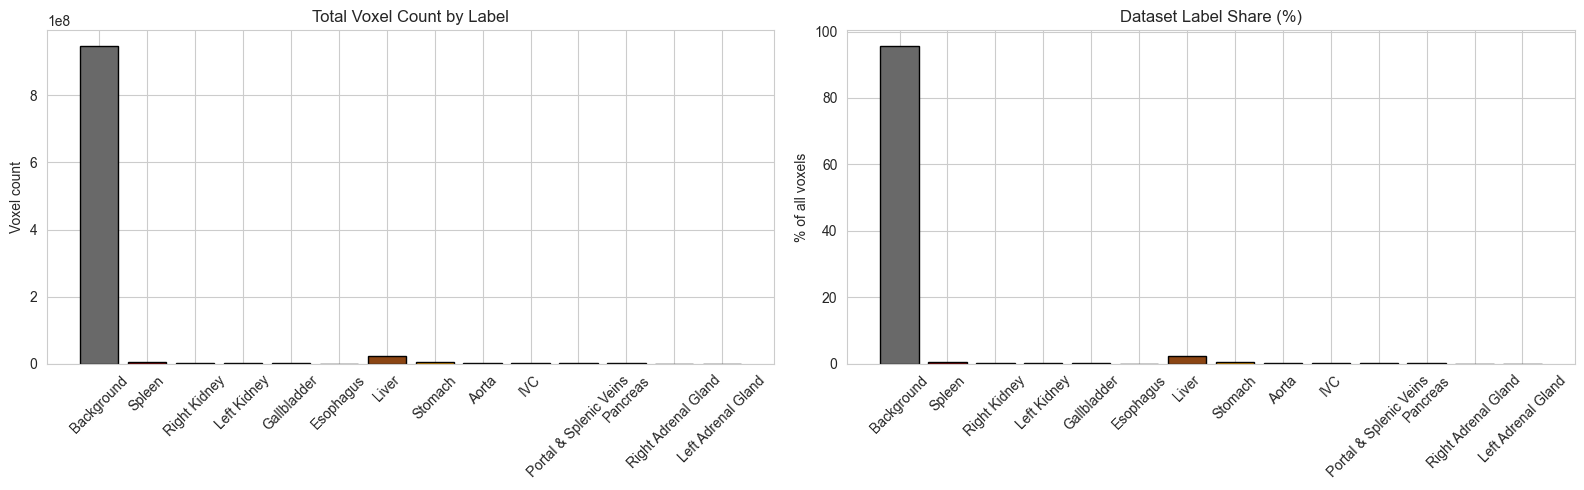

Aggregate label distribution:
  Background          :  946,644,627 voxels (95.559%)
  Spleen              :    4,506,168 voxels ( 0.455%)
  Right Kidney        :    2,213,153 voxels ( 0.223%)
  Left Kidney         :    2,231,972 voxels ( 0.225%)
  Gallbladder         :      363,473 voxels ( 0.037%)
  Esophagus           :      219,664 voxels ( 0.022%)
  Liver               :   23,954,960 voxels ( 2.418%)
  Stomach             :    6,116,001 voxels ( 0.617%)
  Aorta               :    1,363,992 voxels ( 0.138%)
  IVC                 :    1,249,908 voxels ( 0.126%)
  Portal & Splenic Veins:      489,032 voxels ( 0.049%)
  Pancreas            :    1,156,400 voxels ( 0.117%)
  Right Adrenal Gland :       59,218 voxels ( 0.006%)
  Left Adrenal Gland  :       73,608 voxels ( 0.007%)


In [47]:
# Aggregate label distribution across the full dataset
label_items = [(label, name) for label, name in LABEL_NAMES.items()]
label_keys = [(label, name.lower().replace(' ', '_').replace('&', 'and'), name) for label, name in label_items]

total_counts = [df[f'voxels_{key}'].sum() for _, key, _ in label_keys]
total_voxels = sum(total_counts)
label_names_all = [name for _, _, name in label_keys]
label_colors_all = [LABEL_COLORS.get(label, 'lightgray') if label != 0 else 'dimgray' for label, _, _ in label_keys]
label_pcts_all = [100 * count / total_voxels for count in total_counts]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(label_names_all, total_counts, color=label_colors_all, edgecolor='black')
axes[0].set_title('Total Voxel Count by Label')
axes[0].set_ylabel('Voxel count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(label_names_all, label_pcts_all, color=label_colors_all, edgecolor='black')
axes[1].set_title('Dataset Label Share (%)')
axes[1].set_ylabel('% of all voxels')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Aggregate label distribution:')
for (_, _, name), count, pct in zip(label_keys, total_counts, label_pcts_all):
    print(f'  {name:20s}: {count:>12,} voxels ({pct:6.3f}%)')


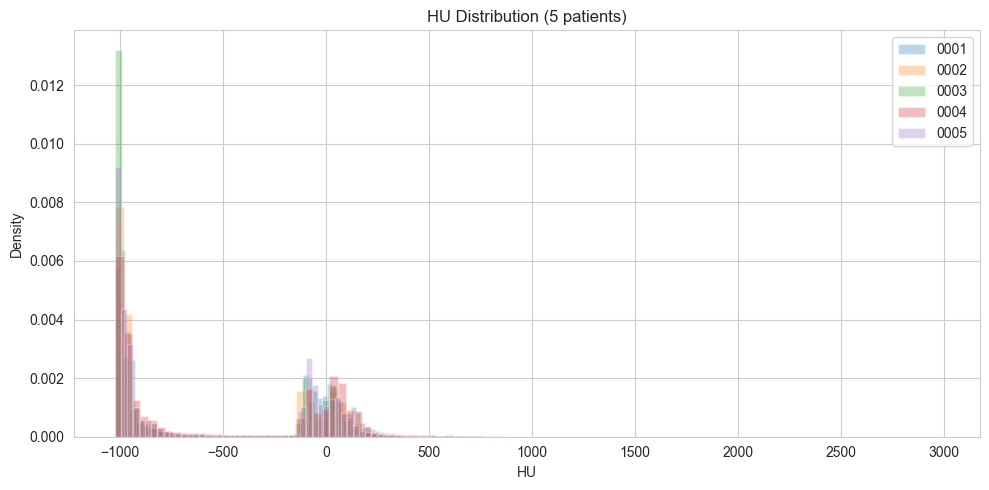

In [48]:
# Intensity distribution (sample from a few patients)
fig, ax = plt.subplots(figsize=(10, 5))
for case_id, ct_path, _ in case_pairs[:5]:
    ct = nib.load(str(ct_path))
    ct_data = ct.get_fdata().flatten()
    sample = np.random.choice(ct_data, size=min(100000, len(ct_data)), replace=False)
    ax.hist(sample, bins=100, alpha=0.3, label=case_id, density=True)

ax.set_xlabel(INTENSITY_LABEL)
ax.set_ylabel("Density")
ax.set_title(f"{INTENSITY_LABEL} Distribution (5 patients)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Anomaly Check

In [49]:
# Check for missing labels or unusual properties
print("Checking for anomalies...\n")

foreground_keys = [
    (label, name.lower().replace(" ", "_").replace("&", "and"), name)
    for label, name in LABEL_NAMES.items()
    if label != 0
]

for _, row in df.iterrows():
    if row["unexpected_labels"]:
        print(f"WARNING: {row.name} has unexpected labels {row['unexpected_labels']}")

    for _, key, label_name in foreground_keys:
        if row[f"voxels_{key}"] == 0:
            print(f"WARNING: {row.name} has 0 voxels for {label_name}!")

    if row["spacing_z"] > 5.0:
        print(f"NOTE: {row.name} has large z-spacing: {row['spacing_z']:.2f} mm")

print("\nDimension summary:")
print(f"  Z slices: {int(df['shape_z'].min())} to {int(df['shape_z'].max())}")
print(f"  In-plane: {int(df['shape_x'].min())}x{int(df['shape_y'].min())} to {int(df['shape_x'].max())}x{int(df['shape_y'].max())}")
print(f"  {INTENSITY_LABEL} range: [{df['intensity_min'].min():.0f}, {df['intensity_max'].max():.0f}]")

if EXPECTED_CASES is not None and len(stats) != EXPECTED_CASES:
    print(f"\nWARNING: Found {len(stats)} patients, expected {EXPECTED_CASES} for this layout.")
else:
    print(f"\nDone! Found {len(stats)} patients for the active layout.")


Checking for anomalies...


Dimension summary:
  Z slices: 85 to 198
  In-plane: 512x512 to 512x512
  HU range: [-3024, 3095]

Done! Found 30 patients for the active layout.
